# `parcelsim` — Synthetic data demo

This notebook runs the complete pipeline **without downloading anything** (no Census, no OSM).  
It uses 3 fictional NYC census tracts to illustrate each step.

Pipeline:
```
City → SyntheticPopulation → ParcelDemand → OperatorAssignment → CARoutingResult → KPIReport
```

In [18]:
!uv pip install -q "parcelsim[viz]"

In [19]:
import os
%matplotlib inline

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import Point, Polygon

import parcelsim
os.makedirs("outputs", exist_ok=True)
print(f"parcelsim {parcelsim.__version__} ✓")

parcelsim 0.1.0 ✓


## 1. City — 3 synthetic census tracts

In [20]:
from parcelsim.city import City

CRS = "EPSG:32618"  # UTM 18N — appropriate for NYC

# Three fictional tracts in projected coordinates (meters)
# Manhattan (dense), Brooklyn (medium), Queens (low density)
zones = gpd.GeoDataFrame(
    {
        "zone_id":      ["36061000100", "36047000100", "36081000100"],
        "name":         ["Manhattan Tract", "Brooklyn Tract", "Queens Tract"],
        "borough":      ["MN", "BK", "QN"],
        "population":   [8_500, 5_200, 3_800],
        "n_households": [4_200, 2_100, 1_500],
        "area_km2":     [0.4,   0.9,   1.2],
        "centroid_x":   [585_000.0, 583_000.0, 590_000.0],
        "centroid_y":   [4_512_000.0, 4_508_000.0, 4_510_000.0],
        "geometry": [
            Polygon([(584_800, 4_511_800), (585_200, 4_511_800), (585_200, 4_512_200), (584_800, 4_512_200)]),
            Polygon([(582_550, 4_507_550), (583_450, 4_507_550), (583_450, 4_508_450), (582_550, 4_508_450)]),
            Polygon([(589_450, 4_509_450), (590_550, 4_509_450), (590_550, 4_510_550), (589_450, 4_510_550)]),
        ],
    },
    geometry="geometry",
    crs=CRS,
)

city = City.from_zones(name="demo_nyc", zones=zones, crs=CRS, country_iso="US")
print(city.zones[["zone_id", "name", "population", "n_households", "area_km2"]])

       zone_id             name  population  n_households  area_km2
0  36061000100  Manhattan Tract        8500          4200       0.4
1  36047000100   Brooklyn Tract        5200          2100       0.9
2  36081000100     Queens Tract        3800          1500       1.2


## 2. Synthetic population — households by income bracket

In [21]:
from parcelsim.population.base import SyntheticPopulation

# Income distribution per tract (share of households in each bracket)
# Manhattan: wealthier | Brooklyn: mixed | Queens: lower income
INCOME_DIST = {
    "36061000100": {"lt35k": 0.15, "35k_65k": 0.20, "65k_100k": 0.25, "gt100k": 0.40},
    "36047000100": {"lt35k": 0.30, "35k_65k": 0.35, "65k_100k": 0.25, "gt100k": 0.10},
    "36081000100": {"lt35k": 0.40, "35k_65k": 0.35, "65k_100k": 0.20, "gt100k": 0.05},
}

AVG_HH_SIZE = {"lt35k": 2.1, "35k_65k": 2.6, "65k_100k": 2.9, "gt100k": 3.1}

rng = np.random.default_rng(42)
rows = []
for _, zone in zones.iterrows():
    zid = zone["zone_id"]
    cx, cy = zone["centroid_x"], zone["centroid_y"]
    for bracket, frac in INCOME_DIST[zid].items():
        n = int(zone["n_households"] * frac)
        for i in range(n):
            # Random jitter around centroid
            jitter = rng.uniform(-200, 200, 2)
            rows.append({
                "household_id": f"{zid}_{bracket}_{i}",
                "zone_id": zid,
                "geometry": Point(cx + jitter[0], cy + jitter[1]),
                "n_persons": max(1, int(rng.normal(AVG_HH_SIZE[bracket], 1))),
                "income_bracket": bracket,
            })

hh_gdf = gpd.GeoDataFrame(rows, geometry="geometry", crs=CRS)
population = SyntheticPopulation(city=city, households=hh_gdf, source_adapter="synthetic", year=2021)

print(population.summary())
print()
print(hh_gdf.groupby(["zone_id", "income_bracket"]).size().unstack(fill_value=0))

SyntheticPopulation [synthetic, 2021]
  City:        demo_nyc
  Households:  7,800
  Persons:     17,609
  Zones:       3
  Income dist: 35k_65k=2,100, gt100k=1,965, 65k_100k=1,875, lt35k=1,860

income_bracket  35k_65k  65k_100k  gt100k  lt35k
zone_id                                         
36047000100         735       525     210    630
36061000100         840      1050    1680    630
36081000100         525       300      75    600


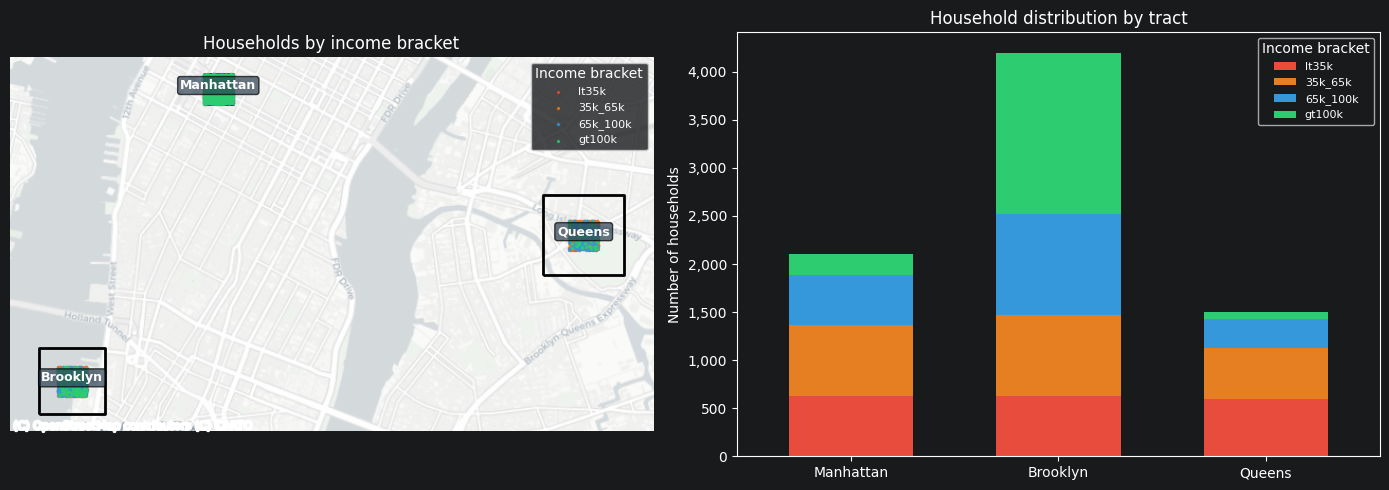

In [22]:
import contextily as ctx

# Visualize household distribution by income
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Map of households colored by income bracket (with basemap)
ax = axes[0]
colors = {"lt35k": "#e74c3c", "35k_65k": "#e67e22", "65k_100k": "#3498db", "gt100k": "#2ecc71"}
zones.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2, zorder=2)
for bracket, color in colors.items():
    sub = hh_gdf[hh_gdf["income_bracket"] == bracket]
    sub.plot(ax=ax, color=color, markersize=2, alpha=0.7, label=bracket, zorder=3)

for _, zone in zones.iterrows():
    ax.annotate(zone["name"].split()[0],
                xy=(zone["centroid_x"], zone["centroid_y"]),
                ha="center", fontsize=9, fontweight="bold", color="white",
                zorder=4,
                bbox=dict(boxstyle="round,pad=0.2", fc="#2c3e50", alpha=0.7))

ctx.add_basemap(ax, crs=zones.crs, source=ctx.providers.CartoDB.Positron, zoom=13)
ax.legend(title="Income bracket", fontsize=8, loc="upper right")
ax.set_title("Households by income bracket")
ax.set_axis_off()

# Stacked bar by zone
ax2 = axes[1]
bracket_counts = hh_gdf.groupby(["zone_id", "income_bracket"]).size().unstack(fill_value=0)
bracket_counts.index = ["Manhattan", "Brooklyn", "Queens"]
bracket_counts[["lt35k", "35k_65k", "65k_100k", "gt100k"]].plot(
    kind="bar", ax=ax2, stacked=True,
    color=[colors[b] for b in ["lt35k", "35k_65k", "65k_100k", "gt100k"]],
    width=0.6
)
ax2.set_title("Household distribution by tract")
ax2.set_xlabel("")
ax2.set_ylabel("Number of households")
ax2.tick_params(axis='x', rotation=0)
ax2.legend(title="Income bracket", fontsize=8)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("outputs/01_population.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Parcel demand — Yang et al. Eq.(1)

$$V_{ad} = \sum_{i \in I} \frac{N_i \cdot U_i \cdot F}{\omega_p \cdot d}$$

- $N_i$ = households in bracket $i$  
- $U_i$ = USPS parcels/week per household (by income)  
- $F$ = e-commerce growth factor (2020→2021 = 1.114)  
- $\omega_p$ = USPS market share (32%)  
- $d$ = working days per week (5)

In [23]:
from parcelsim.demand.usps_model import USPSDemandModel, PARCEL_GENERATION_FACTORS

print("Parcel Generation Factors (USPS weekly parcels/household by income):")
for bracket, u in PARCEL_GENERATION_FACTORS.items():
    print(f"  {bracket:12s}: {u:.2f} parcels/week")

model = USPSDemandModel(
    volume_increase_factor=1.114,   # 2020→2021 e-commerce growth
    usps_market_share=0.32,
    delivery_days_per_week=5,
)

demand = model.generate(population)
print()
print(demand.summary())
print()
print(demand.zone_demand[["zone_id", "n_delivery", "n_pickup"]].round(1))

Parcel Generation Factors (USPS weekly parcels/household by income):
  lt35k       : 0.50 parcels/week
  35k_65k     : 0.72 parcels/week
  65k_100k    : 0.95 parcels/week
  gt100k      : 1.25 parcels/week

ParcelDemand [usps]
  Total delivery (base): 4,651 parcels/day
  Total pickup  (base): 372 parcels/day
  Effective delivery:   4,651 parcels/day
  Zones with demand:    3

       zone_id  n_delivery  n_pickup
0  36061000100      2797.0     223.8
1  36047000100      1117.8      89.4
2  36081000100       735.8      58.9


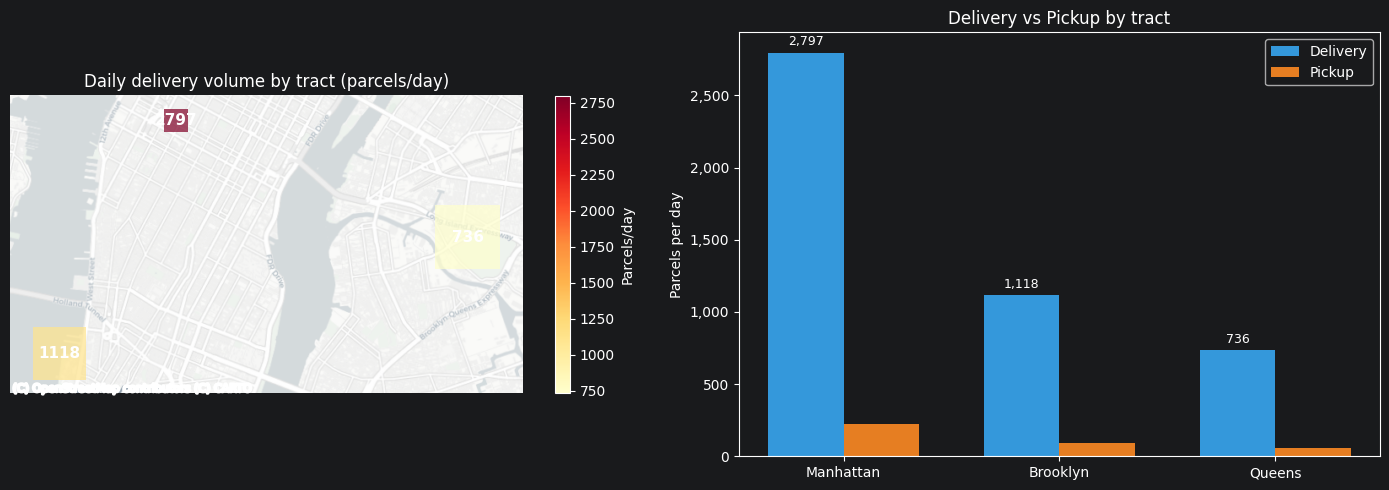


Daily total (all carriers): 4,651 parcels


In [24]:
# Visualize demand by zone
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Demand heat map with basemap
ax = axes[0]
demand.zone_demand.plot(
    column="n_delivery", ax=ax,
    cmap="YlOrRd", alpha=0.7, legend=True,
    legend_kwds={"label": "Parcels/day", "shrink": 0.7},
    zorder=2
)
for _, zone in demand.zone_demand.iterrows():
    ax.annotate(
        f"{zone['n_delivery']:.0f}",
        xy=(zone["centroid_x"], zone["centroid_y"]),
        ha="center", va="center", fontsize=11, fontweight="bold", color="white",
        zorder=3
    )
ctx.add_basemap(ax, crs=demand.zone_demand.crs, source=ctx.providers.CartoDB.Positron, zoom=13)
ax.set_title("Daily delivery volume by tract (parcels/day)")
ax.set_axis_off()

# Bar chart: delivery vs pickup
ax2 = axes[1]
zone_names = ["Manhattan", "Brooklyn", "Queens"]
x = np.arange(len(zone_names))
w = 0.35
deliveries = demand.zone_demand["n_delivery"].values
pickups = demand.zone_demand["n_pickup"].values

bars1 = ax2.bar(x - w/2, deliveries, w, label="Delivery", color="#3498db")
bars2 = ax2.bar(x + w/2, pickups, w, label="Pickup", color="#e67e22")
ax2.set_xticks(x)
ax2.set_xticklabels(zone_names)
ax2.set_ylabel("Parcels per day")
ax2.set_title("Delivery vs Pickup by tract")
ax2.legend()
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

for bar in bars1:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f"{bar.get_height():,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("outputs/02_demand.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nDaily total (all carriers): {demand.total_delivery:,.0f} parcels")

## 4. Operator assignment and depots

In [25]:
from parcelsim.operators.operator import OperatorRegistry
from parcelsim.operators.assignment import assign_parcels

registry = OperatorRegistry.from_builtin("us_2021")
print(registry)
print()
for op in registry.operators:
    print(f"  {op.operator_id:8s} | share={op.market_share:.0%} | depots={len(op.depots)}")

OperatorRegistry([usps(32%), ups(25%), fedex(20%), amazon(23%)])

  usps     | share=32% | depots=8
  ups      | share=25% | depots=9
  fedex    | share=20% | depots=8
  amazon   | share=23% | depots=5


In [26]:
assignment = assign_parcels(demand, registry, city, method="nearest_euclidean")
print(assignment.summary())
print()

# Show assigned depot per tract per operator
cols = ["zone_id"] + [f"{op.operator_id}_depot" for op in registry.operators]
print(assignment.zone_assignments[cols].to_string(index=False))

OperatorAssignment
  usps              1,488 parcels/day
  ups               1,163 parcels/day
  fedex               930 parcels/day
  amazon            1,070 parcels/day

    zone_id      usps_depot             ups_depot          fedex_depot        amazon_depot
36061000100 usps_ny_midtown ups_ny_manhattan_west fedex_ny_manhattan_1 amazon_ny_manhattan
36047000100  usps_ny_morgan ups_ny_manhattan_west fedex_ny_manhattan_1 amazon_ny_manhattan
36081000100 usps_ny_midtown ups_ny_brooklyn_north fedex_ny_manhattan_2   amazon_ny_maspeth


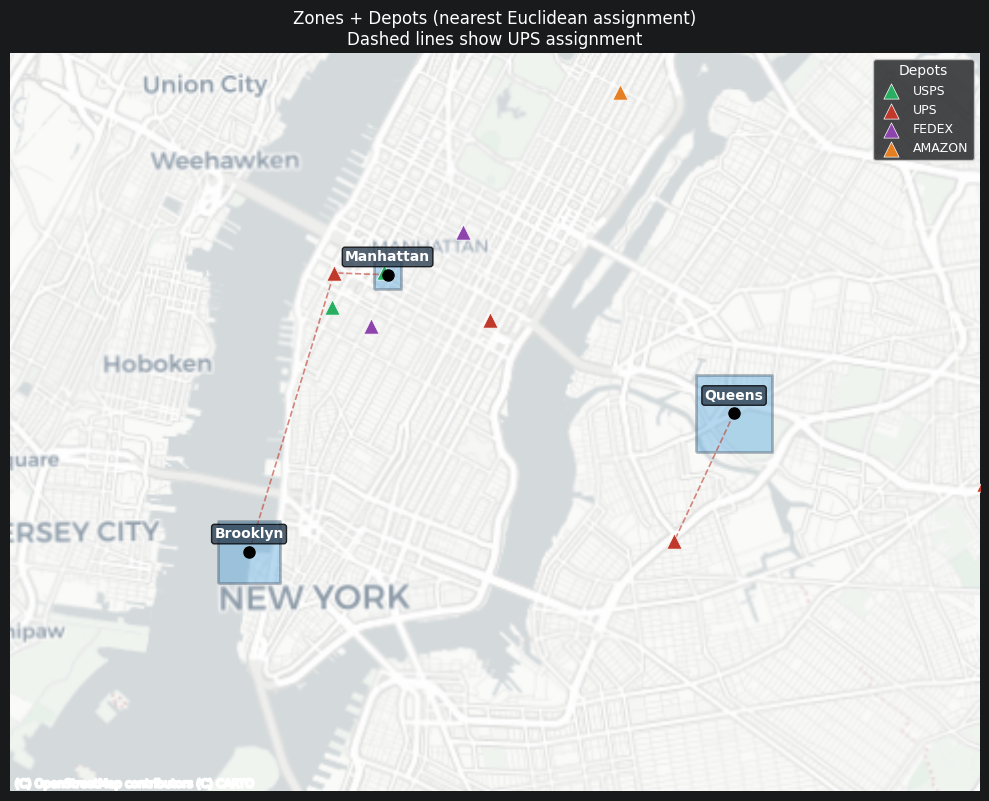

In [27]:
# Map: zones + depots + assignment
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

zones.plot(ax=ax, facecolor="#3498db", edgecolor="#2c3e50", linewidth=2,
           alpha=0.35, zorder=2)

# All carriers' depots
op_colors = {"usps": "#27ae60", "ups": "#c0392b", "fedex": "#8e44ad", "amazon": "#e67e22"}
all_depots_gdf = registry.all_depots(crs="EPSG:4326").to_crs(CRS)

for op_id, color in op_colors.items():
    dep = all_depots_gdf[all_depots_gdf["operator_id"] == op_id]
    dep.plot(ax=ax, color=color, markersize=120, marker="^", zorder=4,
             label=op_id.upper(), edgecolors="white", linewidths=0.5)

# Draw lines from each zone centroid to its assigned UPS depot (as example)
for _, zone in assignment.zone_assignments.iterrows():
    cx, cy = zone["centroid_x"], zone["centroid_y"]
    depot_id = zone["ups_depot"]
    depot_row = all_depots_gdf[all_depots_gdf["depot_id"] == depot_id]
    if not depot_row.empty:
        dx, dy = depot_row.geometry.iloc[0].x, depot_row.geometry.iloc[0].y
        ax.plot([cx, dx], [cy, dy], color="#c0392b", lw=1.2,
                linestyle="--", alpha=0.6, zorder=3)

# Zone centroids
for _, zone in zones.iterrows():
    ax.plot(zone["centroid_x"], zone["centroid_y"], "ko", markersize=8, zorder=5)
    ax.annotate(zone["name"].split()[0],
                xy=(zone["centroid_x"], zone["centroid_y"]),
                xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=10, fontweight="bold", color="white",
                zorder=6,
                bbox=dict(boxstyle="round,pad=0.2", fc="#2c3e50", alpha=0.8))

# Zoom to zones + buffer
bounds = zones.total_bounds
pad = 3_000
ax.set_xlim(bounds[0] - pad, bounds[2] + pad)
ax.set_ylim(bounds[1] - pad, bounds[3] + pad)

ctx.add_basemap(ax, crs=CRS, source=ctx.providers.CartoDB.Positron, zoom=12)
ax.legend(title="Depots", fontsize=9, loc="upper right")
ax.set_title("Zones + Depots (nearest Euclidean assignment)\nDashed lines show UPS assignment")
ax.set_axis_off()

plt.tight_layout()
plt.savefig("outputs/03_assignment.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. CA Router — Continuous Approximation model (Daganzo 1984)

$$V = 2 \cdot r \cdot m + k \cdot (n - m) \cdot \sqrt{\frac{A}{n}}$$

| Variable | Description |
|---|---|
| $V$ | Vehicle-km-traveled (VKT) per service area |
| $r$ | Depot → zone centroid distance (km) |
| $m$ | Number of trucks = $\lceil n/300 \rceil$ |
| $n$ | Number of delivery stops |
| $A$ | Service area (km²) |
| $k$ | Calibrated network coefficient (MN=0.708, BK=0.856) |

In [28]:
from parcelsim.routing.ca.model import CARouter

router = CARouter(truck_capacity=300)
result = router.solve(assignment, city)

print(result.summary())
print()
for op_result in result.operator_results:
    print(f"\n--- {op_result.operator_id.upper()} ---")
    print(op_result.depot_results[["depot_id", "n_stops", "area_km2", "r_km", "k", "m_trucks", "vkt_km"]].round(2).to_string(index=False))

CARoutingResult  scenario=baseline
  Total VKT:         271.6 km/day
  Total trucks:         17
  By operator:
    usps        VKT=      74.8 km  trucks=    5
    ups         VKT=      56.9 km  trucks=    4
    fedex       VKT=      56.6 km  trucks=    4
    amazon      VKT=      83.3 km  trucks=    4


--- USPS ---
       depot_id  n_stops  area_km2  r_km    k  m_trucks  vkt_km
usps_ny_midtown     1130       1.6  2.75 0.71         4   52.00
 usps_ny_morgan      358       0.9  3.73 0.86         1   22.79

--- UPS ---
             depot_id  n_stops  area_km2  r_km    k  m_trucks  vkt_km
ups_ny_brooklyn_north      184       1.2  2.04 0.86         1   16.72
ups_ny_manhattan_west      979       1.3  2.49 0.71         3   40.13

--- FEDEX ---
            depot_id  n_stops  area_km2  r_km    k  m_trucks  vkt_km
fedex_ny_manhattan_1      783       1.3  2.24 0.71         3   35.95
fedex_ny_manhattan_2      147       1.2  4.70 0.86         1   20.69

--- AMAZON ---
           depot_id  n_stops 

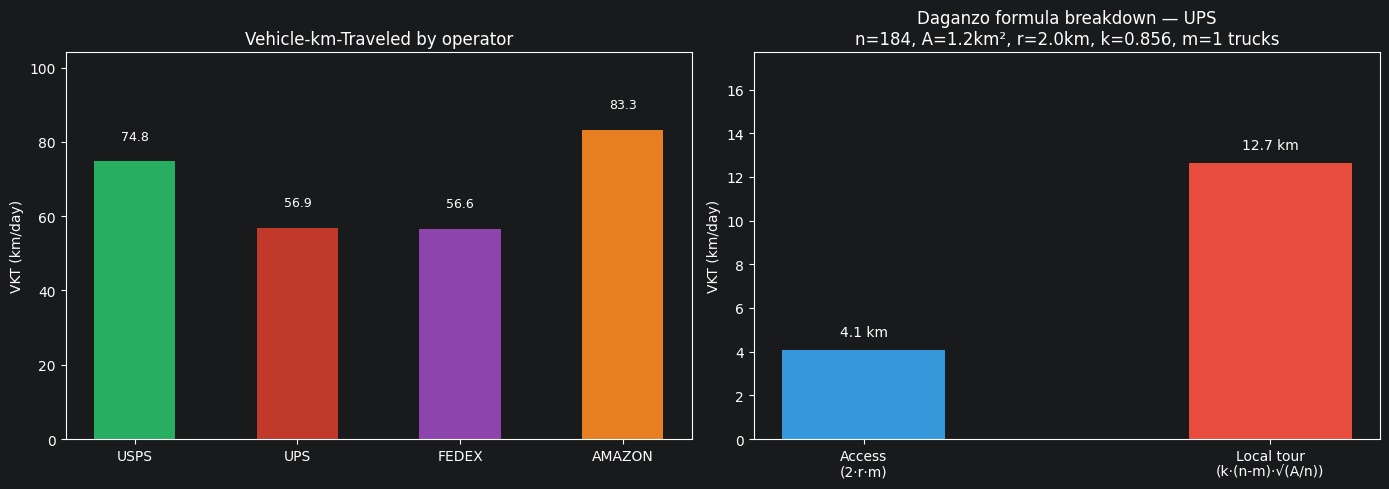

In [29]:
# VKT breakdown: access component (2rm) vs local tour component (k(n-m)√(A/n))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# VKT by operator
ax = axes[0]
op_names = [r.operator_id.upper() for r in result.operator_results]
op_vkt = [r.vkt_total_km for r in result.operator_results]
colors_list = [op_colors.get(r.operator_id, "#95a5a6") for r in result.operator_results]

bars = ax.bar(op_names, op_vkt, color=colors_list, width=0.5)
ax.set_ylabel("VKT (km/day)")
ax.set_title("Vehicle-km-Traveled by operator")
for bar, vkt in zip(bars, op_vkt):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{vkt:,.1f}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, max(op_vkt) * 1.25)

# Daganzo formula breakdown for one operator (UPS as example)
ax2 = axes[1]
ups_result = next(r for r in result.operator_results if r.operator_id == "ups")
if not ups_result.depot_results.empty:
    dr = ups_result.depot_results.iloc[0]
    n, A, r_km, k, m = dr["n_stops"], dr["area_km2"], dr["r_km"], dr["k"], dr["m_trucks"]
    
    access_vkt  = 2 * r_km * m
    local_vkt   = k * (n - m) * np.sqrt(A / n) if n > m and A > 0 else 0
    
    components = ["Access\n(2·r·m)", "Local tour\n(k·(n-m)·√(A/n))"]
    values = [access_vkt, local_vkt]
    bar_colors = ["#3498db", "#e74c3c"]
    
    bars2 = ax2.bar(components, values, color=bar_colors, width=0.4)
    for bar, val in zip(bars2, values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val:,.1f} km", ha="center", va="bottom", fontsize=10)
    ax2.set_ylabel("VKT (km/day)")
    ax2.set_title(f"Daganzo formula breakdown — UPS\n"
                  f"n={n}, A={A:.1f}km², r={r_km:.1f}km, k={k:.3f}, m={m} trucks")
    ax2.set_ylim(0, max(values) * 1.4 if max(values) > 0 else 10)

plt.tight_layout()
plt.savefig("outputs/04_ca_routing.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. KPI Report — Emissions and final metrics

In [30]:
from parcelsim.output.kpi import KPIReport

report = KPIReport.from_ca(result, assignment)
print(report.summary())

──────────────────────────────────────────────────
KPIReport  [CA]  scenario=baseline
──────────────────────────────────────────────────
  Parcels delivered:         4,651 /day
  Parcels picked up:           372 /day
  Total VKT:                 271.6 km/day
  Active trucks:                17
  GHG emissions:              39.5 kg CO₂eq/day
  GHG (MTCE):                 0.04 MTCE/day
  GHG per parcel:              8.5 g CO₂eq
  By operator:
    usps        parcels=   1,488  VKT=     74.8 km  trucks=   5
    ups         parcels=   1,163  VKT=     56.9 km  trucks=   4
    fedex       parcels=     930  VKT=     56.6 km  trucks=   4
    amazon      parcels=   1,070  VKT=     83.3 km  trucks=   4
──────────────────────────────────────────────────


## 7. Scenario analysis

We compare the baseline against three policy scenarios replicating the analyses from the papers.

In [31]:
from parcelsim.scenario.modifiers import (
    demand_growth, peak_season, cargo_bike_substitution
)

scenarios = {
    "Baseline":        None,
    "Peak season":     peak_season(factor=1.104),          # +10.4% demand Q4
    "Demand 2030":     demand_growth(factor=2.0),           # double demand (Hörl et al.)
    "Cargo bikes 17%": cargo_bike_substitution(eligible_fraction=0.17),  # Yang et al.
}

reports = {}
for name, scenario in scenarios.items():
    r = router.solve(assignment, city, scenario=scenario)
    reports[name] = KPIReport.from_ca(r, assignment)

# Comparison table
comparison = pd.DataFrame({
    name: {
        "Parcels/day":      f"{rpt.total_parcels_delivered:,.0f}",
        "VKT (km/day)":     f"{rpt.vkt_total_km:,.1f}",
        "Trucks":           f"{rpt.n_trucks_total:,}",
        "GHG (kg CO₂/day)": f"{rpt.ghg_kg_co2eq:,.1f}",
        "g CO₂/parcel":     f"{rpt.ghg_g_per_parcel:.1f}",
    }
    for name, rpt in reports.items()
})
print(comparison.to_string())

                 Baseline Peak season Demand 2030 Cargo bikes 17%
Parcels/day         4,651       4,651       4,651           4,651
VKT (km/day)        271.6       284.4       432.0           235.2
Trucks                 17          18          31              14
GHG (kg CO₂/day)     39.5        41.4        62.8            34.2
g CO₂/parcel          8.5         8.9        13.5             7.4


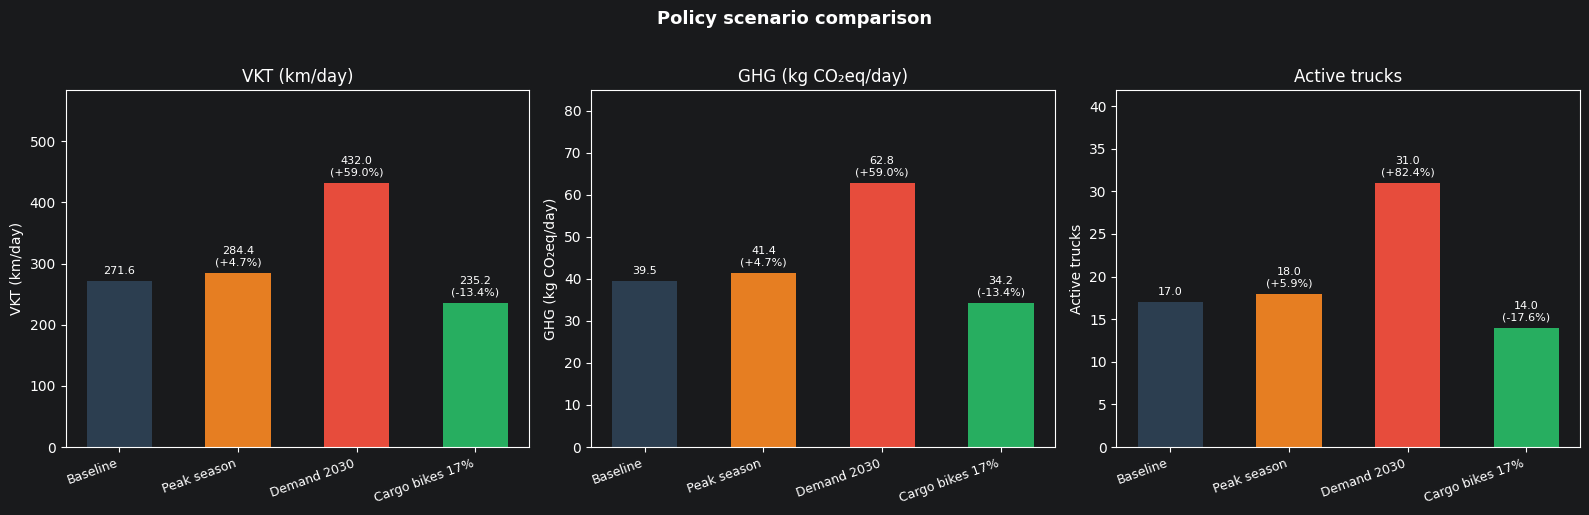

In [32]:
# Scenario comparison chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

scenario_names = list(reports.keys())
scenario_colors = ["#2c3e50", "#e67e22", "#e74c3c", "#27ae60"]

metrics = [
    ("vkt_total_km",    "VKT (km/day)",          axes[0]),
    ("ghg_kg_co2eq",    "GHG (kg CO₂eq/day)",    axes[1]),
    ("n_trucks_total",  "Active trucks",          axes[2]),
]

baseline_vkt = reports["Baseline"].vkt_total_km

for attr, ylabel, ax in metrics:
    values = [getattr(rpt, attr) for rpt in reports.values()]
    bars = ax.bar(range(len(scenario_names)), values,
                  color=scenario_colors, width=0.55)
    ax.set_xticks(range(len(scenario_names)))
    ax.set_xticklabels(scenario_names, rotation=20, ha="right", fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)

    baseline_val = values[0]
    for i, (bar, val) in enumerate(zip(bars, values)):
        label = f"{val:,.1f}"
        if i > 0 and baseline_val > 0:
            pct = (val - baseline_val) / baseline_val * 100
            label += f"\n({pct:+.1f}%)"
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(values) * 0.02,
                label, ha="center", va="bottom", fontsize=8)

    ax.set_ylim(0, max(values) * 1.35)

plt.suptitle("Policy scenario comparison", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/05_scenarios.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Scenario composition

Scenarios are composable with `+`. This replicates the setup from Hörl et al. (2025):  
demand 2030 + cargo bikes.

In [33]:
s_combined = demand_growth(2.0) + cargo_bike_substitution(0.17)
print(f"Combined scenario: '{s_combined.name}'")
print(f"  demand_factor = {s_combined.demand_factor}")
print(f"  peak_factor   = {s_combined.peak_factor}")
print(f"  cargo_bike    = {s_combined.cargo_bike_policy}")

r_combined = router.solve(assignment, city, scenario=s_combined)
report_combined = KPIReport.from_ca(r_combined, assignment)
print()
print(report_combined.summary())

Combined scenario: 'demand_2.0x+cargo_bikes_17pct'
  demand_factor = 0.83
  peak_factor   = 1.0
  cargo_bike    = CargoBikePolicy(eligible_fraction=0.17, max_parcels_per_stop=7, min_bike_lane_fraction=0.1)

──────────────────────────────────────────────────
KPIReport  [CA]  scenario=demand_2.0x+cargo_bikes_17pct
──────────────────────────────────────────────────
  Parcels delivered:         4,651 /day
  Parcels picked up:           372 /day
  Total VKT:                 235.2 km/day
  Active trucks:                14
  GHG emissions:              34.2 kg CO₂eq/day
  GHG (MTCE):                 0.03 MTCE/day
  GHG per parcel:              7.4 g CO₂eq
  By operator:
    usps        parcels=   1,488  VKT=     65.3 km  trucks=   4
    ups         parcels=   1,163  VKT=     53.5 km  trucks=   4
    fedex       parcels=     930  VKT=     49.2 km  trucks=   3
    amazon      parcels=   1,070  VKT=     67.3 km  trucks=   3
──────────────────────────────────────────────────


## 9. Next steps with real data

With real data the pipeline is identical — only the adapter changes:

```python
from parcelsim.population.adapters.census_us import USCensusAdapter

# Downloads ACS 2020 for the 5 NYC boroughs (~2 min, cached)
city = City.from_osmnx("New York City, New York, USA", crs="EPSG:32618")
population = USCensusAdapter(
    state="NY",
    county_fips=["061", "047", "081", "005", "085"],
    acs_year=2020,
).build(city)

# The rest of the pipeline is exactly the same ↓
demand     = USPSDemandModel(volume_increase_factor=1.114).generate(population)
registry   = OperatorRegistry.from_builtin("us_2021")
assignment = assign_parcels(demand, registry, city)
result     = CARouter().solve(assignment, city)
report     = KPIReport.from_ca(result, assignment)
# → Target: ~1.91M parcels/day, ~98,871 km VKT/day (Yang et al. Table 4)
```

In [34]:
# Final summary
print("=" * 55)
print("PIPELINE SUMMARY parcelsim v0.1")
print("=" * 55)
steps = [
    ("1. City",          f"{len(city.zones)} tracts"),
    ("2. Population",    f"{population.n_households:,} households"),
    ("3. Demand",        f"{demand.total_delivery:,.0f} parcels/day"),
    ("4. Operators",     f"{len(registry.operators)} carriers, {sum(len(op.depots) for op in registry.operators)} depots"),
    ("5. CA Router",     f"{report.vkt_total_km:,.1f} km VKT/day"),
    ("6. Emissions",     f"{report.ghg_kg_co2eq:,.1f} kg CO₂eq/day"),
    ("7. Scenarios",     f"{len(scenarios)} scenarios run"),
]
for step, value in steps:
    print(f"  {step:20s} → {value}")
print("=" * 55)

PIPELINE SUMMARY parcelsim v0.1
  1. City              → 3 tracts
  2. Population        → 7,800 households
  3. Demand            → 4,651 parcels/day
  4. Operators         → 4 carriers, 30 depots
  5. CA Router         → 271.6 km VKT/day
  6. Emissions         → 39.5 kg CO₂eq/day
  7. Scenarios         → 4 scenarios run
